# Задание 2.2. Задача трёх тел
## Зелёный уровень: звезда и две лёгкие планеты

**Цель:** реализовать плоское движение трёх взаимно притягивающихся тел методами RK4 и Верле, сравнить расчёты при разных шагах и проверить сохранение энергии и момента импульса.

Все расчёты ведутся в системе СИ: координаты в метрах, скорости в м/с, массы в килограммах, время в секундах. Используется физическая гравитационная постоянная $G=6.67430\cdot10^{-11}\ {\rm м^3/(кг\,с^2)}$. Для чтения графиков координаты показываются в астрономических единицах (а.е.), время — в годах. Звезда движется наравне с планетами; неподвижного притягивающего центра в модели нет.

### 1. Уравнения и начальные условия

Пусть $\mathbf r_i=(x_i,y_i)$ и $\mathbf v_i=(v_{x,i},v_{y,i})$. Тогда
$$\dot{\mathbf r}_i=\mathbf v_i,\qquad
\dot{\mathbf v}_i=G\sum_{j\ne i}m_j
\frac{\mathbf r_j-\mathbf r_i}{|\mathbf r_j-\mathbf r_i|^3}.$$

Масса звезды равна массе Солнца $M_\odot=1.98847\cdot10^{30}$ кг. Массы планет составляют $0.001M_\odot$ и $0.002M_\odot$ (примерно массы Юпитера и двух Юпитеров). Начальные расстояния от звезды: $R_1=1$ а.е. и $R_2=2.5$ а.е., где $1\ {\rm а.е.}=149\,597\,870\,700$ м. Планеты стартуют с разностью углов $120^\circ$ и движутся в одном направлении. Их начальные скорости относительно звезды направлены по касательной и выбраны как
$$v_i=\sqrt{\frac{G(m_0+m_i)}{R_i}}.$$
Здесь $R_i$ подставляется в метрах, поэтому скорость получается в м/с. Эта формула даёт круговую относительную орбиту в изолированной задаче двух тел. В нашей системе есть ещё одно тело, поэтому орбиты лишь приближённо круговые.

Перейдём в систему центра масс, вычитая **одни и те же** векторы из координат и скоростей всех тел:
$$\mathbf R_{\rm cm}=\frac{\sum_i m_i\mathbf r_i}{\sum_i m_i},\qquad
\mathbf V_{\rm cm}=\frac{\sum_i m_i\mathbf v_i}{\sum_i m_i}.$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 110, "font.size": 10,
                     "axes.spines.top": False, "axes.spines.right": False})

G = 6.67430e-11                 # м^3/(кг·с^2)
M_SUN = 1.98847e30              # кг
AU = 149_597_870_700.0          # м
YEAR = 365.25*24*60*60.0        # с
mass = M_SUN*np.array([1.0, 0.001, 0.002])  # кг
body_names = ["Звезда", "Планета 1", "Планета 2"]
body_colors = ["#77549c", "#147d92", "#d97732"]
method_colors = {"RK4": "#147d92", "Верле": "#d97732"}

r0 = np.zeros((3, 2))
v0 = np.zeros((3, 2))
for i, radius_au, angle in [(1, 1.0, 0.0), (2, 2.5, 2*np.pi/3)]:
    radius = radius_au*AU
    r0[i] = radius*np.array([np.cos(angle), np.sin(angle)])
    speed = np.sqrt(G*(mass[0]+mass[i])/radius)
    v0[i] = speed*np.array([-np.sin(angle), np.cos(angle)])

r0 -= np.sum(mass[:, None]*r0, axis=0)/mass.sum()
v0 -= np.sum(mass[:, None]*v0, axis=0)/mass.sum()
initial = np.stack([r0, v0])  # форма (2, 3, 2): координаты/скорости, тела, x/y

print("Начальный центр масс (м):", np.sum(mass[:, None]*r0, axis=0)/mass.sum())
print("Начальный импульс (кг·м/с):", np.sum(mass[:, None]*v0, axis=0))
print(f"G = {G:.5e} м³/(кг·с²); 1 а.е. = {AU:.0f} м; 1 год = {YEAR:.0f} с")
print("Массы тел (кг):", mass)

Начальный центр масс (м): [-7.57686745e-08 -7.57686745e-08]
Начальный импульс (кг·м/с): [0. 0.]
G = 6.67430e-11 м³/(кг·с²); 1 а.е. = 149597870700 м; 1 год = 31557600 с
Массы тел (кг): [1.98847e+30 1.98847e+27 3.97694e+27]


### 2. Сила притяжения и численные методы

Каждую пару тел обрабатываем один раз. Вклад в ускорение первого тела пропорционален массе второго, и наоборот. Силы пары равны по модулю и противоположны по направлению. Ускорение звезды вычисляется тем же способом, что и ускорения планет.

Для RK4 запишем состояние как $q=(\mathbf r,\mathbf v)$, а правую часть как $f(q)=(\mathbf v,\mathbf a(\mathbf r))$. В промежуточных стадиях RK4 координаты и скорости складываются с соответствующими множителями шага времени, поэтому все состояния сохраняют размерности м и м/с. Один шаг:
$$k_1=f(q_n),\quad k_2=f(q_n+hk_1/2),\quad
k_3=f(q_n+hk_2/2),\quad k_4=f(q_n+hk_3),$$
$$q_{n+1}=q_n+\frac h6(k_1+2k_2+2k_3+k_4).$$

Используем скоростную форму метода Верле (*velocity Verlet*):
$$\mathbf v_{n+1/2}=\mathbf v_n+\frac h2\mathbf a(\mathbf r_n),$$
$$\mathbf r_{n+1}=\mathbf r_n+h\mathbf v_{n+1/2},$$
$$\mathbf v_{n+1}=\mathbf v_{n+1/2}+\frac h2\mathbf a(\mathbf r_{n+1}).$$
RK4 имеет четвёртый порядок точности, Верле — второй. Скоростная форма удобна тем, что координаты и скорости известны в одинаковые моменты времени.

In [2]:
def acceleration(r):
    a = np.zeros_like(r)
    for i in range(3):
        for j in range(i+1, 3):
            delta = r[j]-r[i]
            distance = np.linalg.norm(delta)
            if distance == 0:
                raise ValueError("Столкновение: расстояние между телами равно нулю")
            pair = G*delta/distance**3
            a[i] += mass[j]*pair
            a[j] -= mass[i]*pair
    return a


def rhs(q):
    return np.stack([q[1], acceleration(q[0])])


def rk4_step(q, h):
    k1 = rhs(q)
    k2 = rhs(q+h*k1/2)
    k3 = rhs(q+h*k2/2)
    k4 = rhs(q+h*k3)
    return q+h*(k1+2*k2+2*k3+k4)/6


def verlet_step(q, h):
    r, v = q
    half_velocity = v+h*acceleration(r)/2
    new_r = r+h*half_velocity
    new_v = half_velocity+h*acceleration(new_r)/2
    return np.stack([new_r, new_v])


def integrate(method, n_steps, end_time):
    step = {"RK4": rk4_step, "Верле": verlet_step}[method]
    times = np.linspace(0.0, end_time, n_steps+1)
    h = end_time/n_steps
    states = np.empty((n_steps+1, 2, 3, 2))
    states[0] = initial
    for n in range(n_steps):
        states[n+1] = step(states[n], h)
    return times, states

### 3. Расчёты и контролируемые величины

Время расчёта составляет $T=2.009\cdot10^8$ с, или примерно 6.366 года, что соответствует примерно 6.37 оборота внутренней планеты. Рассмотрим пять шагов интегрирования: h=4.651,  2.325, 1.163, 0.581, 0.291 суток. В вычислениях время и шаг хранятся в секундах. Сглаживание гравитационной силы не используется.

Для изолированной системы сохраняются полная механическая энергия (Дж) и полный момент импульса (кг·м²/с):
$$E=\frac12\sum_i m_i|\mathbf v_i|^2-
G\sum_{i<j}\frac{m_im_j}{|\mathbf r_i-\mathbf r_j|},$$
$$L_z=\sum_i m_i(x_i v_{y,i}-y_i v_{x,i}).$$
Каждая пара в потенциальной энергии учитывается один раз. Поскольку движение плоское, у момента импульса есть только компонента вдоль оси $z$.

Расчёт уже начинается в системе центра масс. Для диагностики используем исходные численные состояния: **центр масс и импульс во время интегрирования принудительно не исправляются**. Это позволяет заметить их возможный численный дрейф.

In [3]:
def diagnostics(states):
    r = states[:, 0]  # форма (число моментов, 3 тела, 2 координаты)
    v = states[:, 1]
    kinetic = 0.5*np.sum(mass[None, :]*np.sum(v*v, axis=2), axis=1)
    potential = np.zeros(len(states))
    distances = []
    for i in range(3):
        for j in range(i+1, 3):
            distance = np.linalg.norm(r[:, j]-r[:, i], axis=1)
            potential -= G*mass[i]*mass[j]/distance
            distances.append(distance)
    angular = np.sum(mass[None, :]*(r[:, :, 0]*v[:, :, 1]
                                   - r[:, :, 1]*v[:, :, 0]), axis=1)
    center = np.sum(mass[None, :, None]*r, axis=1)/mass.sum()
    momentum = np.sum(mass[None, :, None]*v, axis=1)
    return {"E": kinetic+potential, "L": angular, "center": center,
            "P": momentum, "min_distance": np.min(distances)}


duration = 40.0*np.sqrt(AU**3/(G*M_SUN))  # с; около 6.37 года
counts = np.array([500, 1000, 2000, 4000, 8000])
steps = duration/counts
runs = {}
for method in method_colors:
    for n in counts:
        t, q = integrate(method, int(n), duration)
        runs[method, int(n)] = {"t": t, "q": q, **diagnostics(q)}

base = runs["RK4", 1000]
print(f"Начальная энергия E0 = {base['E'][0]:.6e} Дж")
print(f"Начальный момент L0 = {base['L'][0]:.6e} кг·м²/с")
print(f"Время расчёта: {duration/YEAR:.3f} года")
print(f"Шаги интегрирования, сутки: {steps/86400}")

Начальная энергия E0 = -1.587685e+36 Дж
Начальный момент L0 = 3.687402e+43 кг·м²/с
Время расчёта: 6.366 года
Шаги интегрирования, сутки: [4.65052495 2.32526248 1.16263124 0.58131562 0.29065781]


### 4. Траектории всех трёх тел

Сравним траектории при $h=2.33$ суток. На верхних панелях показана вся система, на нижних — увеличенное движение звезды. Кружками обозначены начальные положения. Масштаб по осям $x$ и $y$ одинаков в каждой панели.

У звезды маленькая, но ненулевая траектория: её движение обеспечивает сохранение общего центра масс. На общем масштабе это движение почти не видно, поэтому отдельное увеличение существенно.

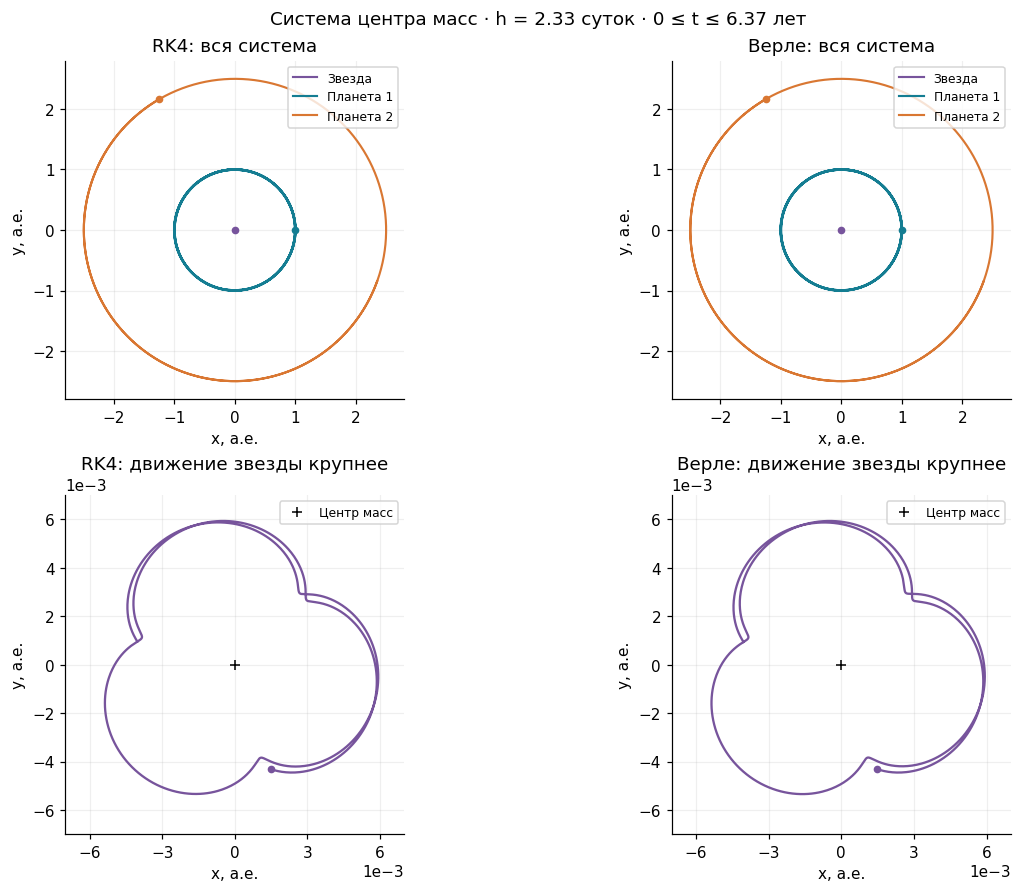

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8), constrained_layout=True)
for col, method in enumerate(method_colors):
    positions = runs[method, 1000]["q"][:, 0]/AU
    for i, name in enumerate(body_names):
        axes[0, col].plot(positions[:, i, 0], positions[:, i, 1],
                          color=body_colors[i], lw=1.4, label=name)
        axes[0, col].plot(*positions[0, i], "o", color=body_colors[i], ms=4)
    axes[0, col].set_title(f"{method}: вся система")
    axes[0, col].set_xlim(-2.8, 2.8)
    axes[0, col].set_ylim(-2.8, 2.8)
    axes[0, col].legend(loc="upper right", fontsize=8)

    axes[1, col].plot(positions[:, 0, 0], positions[:, 0, 1],
                      color=body_colors[0], lw=1.5)
    axes[1, col].plot(*positions[0, 0], "o", color=body_colors[0], ms=4)
    axes[1, col].plot(0, 0, "+", color="black", label="Центр масс")
    axes[1, col].set_title(f"{method}: движение звезды крупнее")
    axes[1, col].set_xlim(-0.007, 0.007)
    axes[1, col].set_ylim(-0.007, 0.007)
    axes[1, col].set_xticks(np.linspace(-0.006, 0.006, 5))
    axes[1, col].ticklabel_format(axis="both", style="sci", scilimits=(-3, -3), useOffset=False)
    axes[1, col].legend(loc="upper right", fontsize=8)

for ax in axes.flat:
    ax.set(xlabel="x, а.е.", ylabel="y, а.е.")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)
fig.suptitle(f"Система центра масс · h = {steps[1]/86400:.2f} суток · 0 ≤ t ≤ {duration/YEAR:.2f} лет")
plt.show()

### 5. Энергия и момент импульса во времени

Сначала построим сами $E(t)$ и $L_z(t)$ для обоих методов. Затем рассмотрим относительные отклонения
$$\delta E(t)=\frac{E(t)-E(0)}{|E(0)|},\qquad
\delta L(t)=\frac{L_z(t)-L_z(0)}{|L_z(0)|}.$$
У выбранных начальных данных оба знаменателя ненулевые. На графиках отклонений масштаб по вертикали у разных методов различается: он указан у каждой оси.

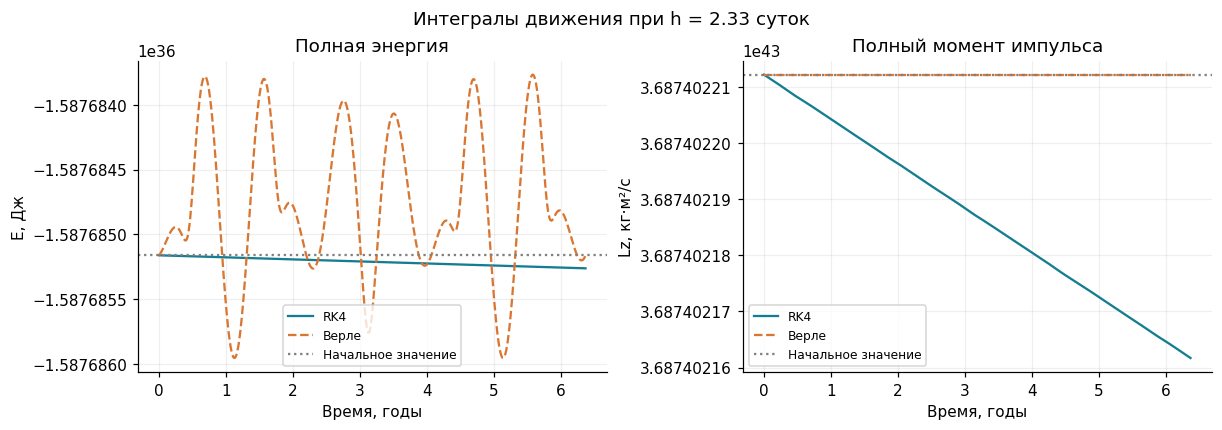

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), constrained_layout=True)
for method, color in method_colors.items():
    run = runs[method, 1000]
    for ax, key in zip(axes, ["E", "L"]):
        ax.plot(run["t"]/YEAR, run[key], color=color,
                linestyle="-" if method == "RK4" else "--", label=method)
for ax, key, title in zip(axes, ["E", "L"], ["Полная энергия", "Полный момент импульса"]):
    ax.axhline(base[key][0], color="gray", linestyle=":", label="Начальное значение")
    ax.set(title=title, xlabel="Время, годы", ylabel="E, Дж" if key == "E" else "Lz, кг·м²/с")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useOffset=False)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8)
fig.suptitle(f"Интегралы движения при h = {steps[1]/86400:.2f} суток")
plt.show()

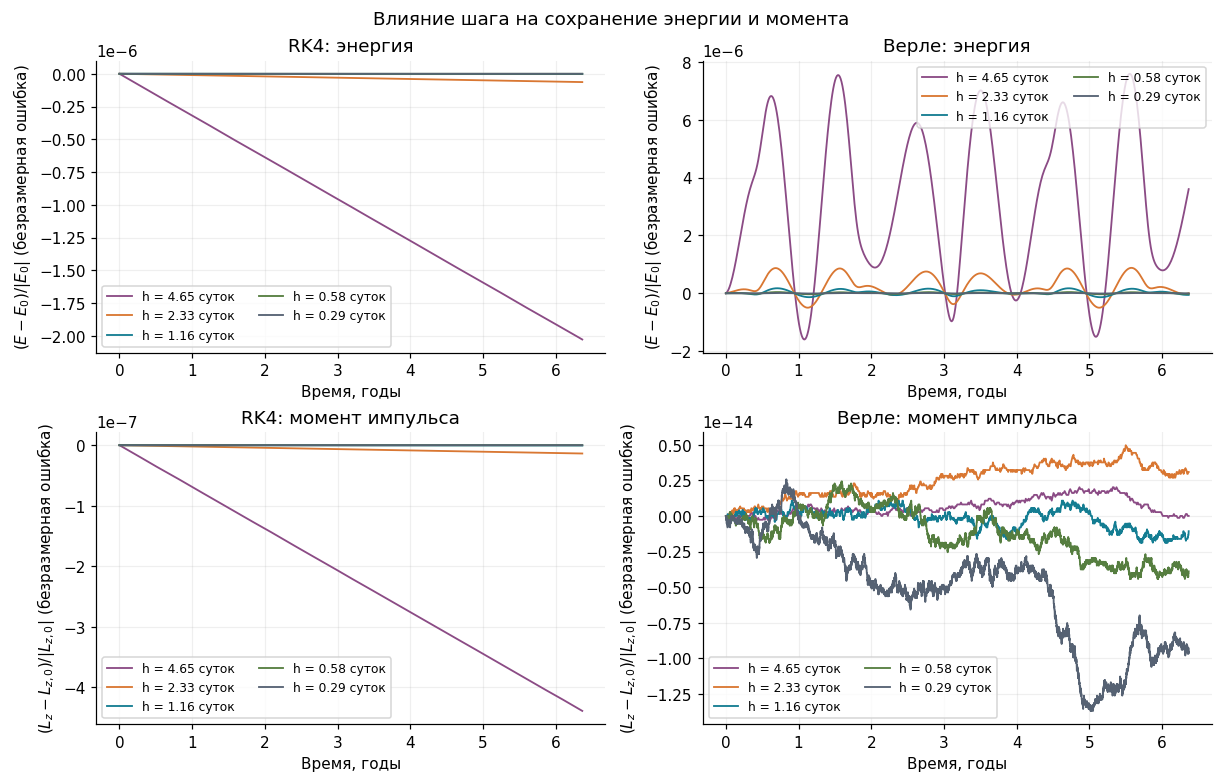

Метод        h, суток      max |δE/E0|      max |δL/L0|
RK4             4.651      2.02768e-06      4.38807e-07
RK4             2.325      6.32915e-08      1.37011e-08
RK4             1.163      1.97670e-09      4.28176e-10
RK4             0.581      6.17177e-11      1.33804e-11
RK4             0.291      1.92832e-12      4.19249e-13
Верле           4.651      7.58974e-06      2.01433e-15
Верле           2.325      8.78385e-07      4.96868e-15
Верле           1.163      1.72946e-07      1.88004e-15
Верле           0.581      4.06176e-08      4.43152e-15
Верле           0.291      9.99376e-09      1.36974e-14


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), constrained_layout=True)
step_colors = ["#8b4b85", "#d97732", "#147d92", "#567e40", "#566273"]
for col, method in enumerate(method_colors):
    for n, h, color in zip(counts, steps, step_colors):
        run = runs[method, int(n)]
        for row, key in enumerate(["E", "L"]):
            deviation = (run[key]-run[key][0])/abs(run[key][0])
            axes[row, col].plot(run["t"]/YEAR, deviation, lw=1.2, color=color, label=f"h = {h/86400:.2f} суток")
    axes[0, col].set_title(f"{method}: энергия")
    axes[1, col].set_title(f"{method}: момент импульса")
    axes[0, col].set_ylabel(r"$(E-E_0)/|E_0|$ (безразмерная ошибка)")
    axes[1, col].set_ylabel(r"$(L_z-L_{z,0})/|L_{z,0}|$ (безразмерная ошибка)")
for ax in axes.flat:
    ax.set_xlabel("Время, годы")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useOffset=False)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=8, ncol=2)
fig.suptitle("Влияние шага на сохранение энергии и момента")
plt.show()

print(f"{'Метод':<8} {'h, суток':>12} {'max |δE/E0|':>16} {'max |δL/L0|':>16}")
for method in method_colors:
    for n, h in zip(counts, steps):
        run = runs[method, int(n)]
        energy_error = np.max(np.abs((run["E"]-run["E"][0])/abs(run["E"][0])))
        angular_error = np.max(np.abs((run["L"]-run["L"][0])/abs(run["L"][0])))
        print(f"{method:<8} {h/86400:12.3f} {energy_error:16.5e} {angular_error:16.5e}")

У Верле момент импульса сохраняется в точной арифметике: на каждом изменении скорости силы центральные, а при переносе координат добавка к моменту содержит $\mathbf v\times\mathbf v=0$. Остаточные отклонения в расчёте связаны с округлением, поэтому они не обязаны уменьшаться при дроблении шага.

Энергия выражена в джоулях, момент импульса — в кг·м²/с. Графики отклонений и ошибки положения относительно численного ориентира показывают безразмерные отношения. Шаг указан в сутках, время — в годах.

Верле не сохраняет исходную энергию абсолютно точно. На рассмотренном интервале её ошибка колеблется; амплитуда зависит от шага. RK4 при этих же шагах даёт меньшую ошибку энергии, но также допускает её накопление. Выводы относятся к выбранным начальным данным и времени $T=40$.

### 6. Проверка сходимости координат

Хорошее сохранение энергии само по себе не гарантирует правильного положения планеты на орбите. Поэтому сравним координаты при уменьшении шага.

Простого точного решения для выбранной конфигурации нет. В качестве численного ориентира используем RK4 с $h_{\rm ref}=0.00125$ и дополнительно сравним его с расчётом при $h=0.0025$. Оба расчёта выполняются для той же полной системы трёх тел. Это **численный ориентир**, а не аналитическое решение.

Ошибка положения оценивается как
$$\varepsilon_h=\max_{n,i}\|\mathbf r_i^{(h)}(t_n)-\mathbf r_i^{(\rm ref)}(t_n)\|_2.$$
Сетки вложенные, поэтому значения сравниваются в совпадающие моменты без интерполяции. При делении шага пополам оценка порядка равна
$$p\approx\log_2\frac{\varepsilon_h}{\varepsilon_{h/2}}.$$

Изменение координат RK4 между h = 0.145 и 0.073 суток: 5.280e-03 км
Метод        h, суток    max ошибка r, км    Порядок
RK4             4.651         2.18178e+04          —
RK4             2.325         8.52793e+02      4.677
RK4             1.163         3.73437e+01      4.513
RK4             0.581         1.83488e+00      4.347
RK4             0.291         9.87354e-02      4.216
Верле           4.651         1.23949e+07          —
Верле           2.325         3.10541e+06      1.997
Верле           1.163         7.76733e+05      1.999
Верле           0.581         1.94206e+05      2.000
Верле           0.291         4.85530e+04      2.000


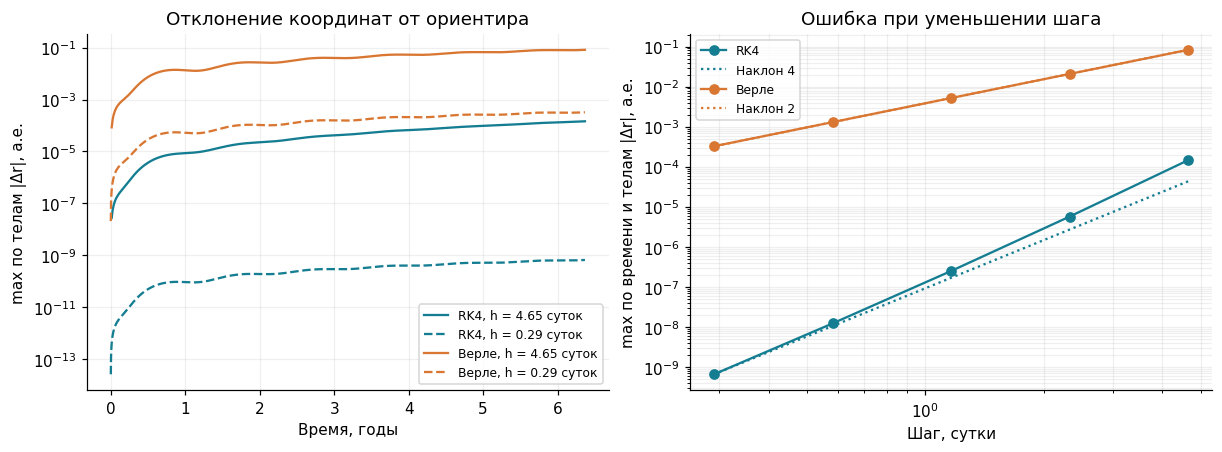

In [6]:
reference_count = 32000
ref_t, ref_q = integrate("RK4", reference_count, duration)
_, check_q = integrate("RK4", 16000, duration)
reference_change = np.linalg.norm(check_q[:, 0]-ref_q[::2, 0], axis=2).max()

position_errors = {}
error_curves = {}
print(f"Изменение координат RK4 между h = {duration/16000/86400:.3f} и {duration/32000/86400:.3f} суток: {reference_change/1000:.3e} км")
print(f"{'Метод':<8} {'h, суток':>12} {'max ошибка r, км':>19} {'Порядок':>10}")
for method in method_colors:
    values = []
    for n, h in zip(counts, steps):
        run = runs[method, int(n)]
        stride = reference_count//int(n)
        reference_on_grid = ref_q[::stride, 0]
        difference = np.linalg.norm(run["q"][:, 0]-reference_on_grid, axis=2)
        curve = np.max(difference, axis=1)
        error_curves[method, int(n)] = curve
        values.append(curve.max())
    position_errors[method] = np.array(values)
    orders = np.log2(position_errors[method][:-1]/position_errors[method][1:])
    for i, (h, value) in enumerate(zip(steps, values)):
        order_text = "—" if i == 0 else f"{orders[i-1]:.3f}"
        print(f"{method:<8} {h/86400:12.3f} {value/1000:19.5e} {order_text:>10}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
for method, color in method_colors.items():
    for n, line in [(500, "-"), (8000, "--")]:
        run = runs[method, n]
        curve = error_curves[method, n]
        axes[0].semilogy(run["t"][1:]/YEAR, curve[1:]/AU, line, color=color,
                         label=f"{method}, h = {duration/n/86400:.2f} суток")
    axes[1].loglog(steps/86400, position_errors[method]/AU, "o-", color=color, label=method)
    order = 4 if method == "RK4" else 2
    guide = position_errors[method][-1]*(steps/steps[-1])**order
    axes[1].loglog(steps/86400, guide/AU, ":", color=color, label=f"Наклон {order}")
axes[0].set(title="Отклонение координат от ориентира", xlabel="Время, годы", ylabel="max по телам |Δr|, а.е.")
axes[1].set(title="Ошибка при уменьшении шага", xlabel="Шаг, сутки", ylabel="max по времени и телам |Δr|, а.е.")
for ax in axes:
    ax.grid(which="both", alpha=0.2)
    ax.legend(fontsize=8)
plt.show()

На правом графике обе оси логарифмические. Если $\varepsilon_h\approx Ch^p$, то
$\log\varepsilon_h\approx\log C+p\log h$: наклон равен порядку $p$. При $p\approx4$ уменьшение шага вдвое снижает ошибку примерно в 16 раз, при $p\approx2$ — в 4 раза. Порядок здесь проверяется по координатам, а не по энергии, у которой зависимость от шага может быть иной.

### 7. Проверки и выводы

Проверим, что центр масс остаётся около начала координат, полный импульс — около нуля, а между телами нет столкновений на выбранном интервале. Также проверим уменьшение ошибки положения при сгущении сетки и достаточную точность численного ориентира.

In [7]:
max_center = max(np.linalg.norm(run["center"], axis=1).max() for run in runs.values())
max_momentum = max(np.linalg.norm(run["P"], axis=1).max() for run in runs.values())
min_distance = min(run["min_distance"] for run in runs.values())
assert all(np.isfinite(run["q"]).all() for run in runs.values())
assert max_center < AU*1e-10 and max_momentum < mass.sum()*np.sqrt(G*M_SUN/AU)*1e-10
assert min_distance > 0.5*AU
assert all(np.all(np.diff(values) < 0) for values in position_errors.values())
assert reference_change < 0.1*min(values[-1] for values in position_errors.values())

print(f"Максимальное смещение центра масс: {max_center/AU:.3e} а.е.")
print(f"Максимальный модуль полного импульса: {max_momentum:.3e} кг·м/с")
print(f"Минимальное расстояние между телами на узлах: {min_distance/AU:.6f} а.е.")
print("Проверки пройдены.")

Максимальное смещение центра масс: 5.650e-16 а.е.
Максимальный модуль полного импульса: 1.656e+18 кг·м/с
Минимальное расстояние между телами на узлах: 0.998844 а.е.
Проверки пройдены.


1. Получена иерархическая система: две лёгкие планеты обращаются около массивной звезды, внутренняя планета движется быстрее внешней. На увеличенных графиках видно движение самой звезды относительно центра масс.
2. Уменьшение шага снижает ошибку координат обоих методов. Для Верле оценка порядка близка к двум. У RK4 она приближается к четырём при уменьшении шага; на конечной сетке вклад членов более высокого порядка ещё заметен. При одном и том же шаге RK4 точнее в этом эксперименте; сравнение скорости вычислений здесь не проводилось.
3. Энергия и момент импульса остаются близки к начальным значениям. У Верле видны колебания ошибки энергии, а момент сохраняется до ошибок округления. У RK4 на выбранном интервале ошибки интегралов малы, но наблюдается дрейф.
4. Центр масс и полный импульс сохраняются с высокой точностью без принудительной коррекции. Это согласуется с тем, что учитываются движения всех трёх тел и парные силы взаимного притяжения.

Таким образом, все требования зелёного уровня выполнены: два метода, несколько шагов, траектории в системе центра масс и графики изменения полной энергии и полного момента импульса.